In [10]:
!pip -q install sentence-transformers faiss-cpu

In [11]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJ = '/content/drive/MyDrive/airline-cx-copilot'
DATA = f'{PROJ}/data'
assert os.path.exists(f'{DATA}/reviews_sample.parquet'), 'Run notebook 1 first'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import json
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer

sample = pd.read_parquet(f'{DATA}/reviews_sample.parquet').reset_index(drop=True)
texts = sample['review_text'].tolist()
print(len(texts), 'reviews')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)
model.max_seq_length = 256

emb = model.encode(texts, batch_size=128, show_progress_bar=True, normalize_embeddings=True).astype('float32')
np.save(f'{DATA}/embeddings.npy', emb)
print('embeddings:', emb.shape, round(emb.nbytes / 1e6, 1), 'MB')

8000 reviews
device: cuda


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

embeddings: (8000, 384) 12.3 MB


In [13]:
import faiss

index = faiss.IndexFlatIP(emb.shape[1])   # inner product on normalized vectors = cosine similarity
index.add(emb)
faiss.write_index(index, f'{DATA}/faiss.index')
print('vectors in index:', index.ntotal)

def search(query, k=5):
    qv = model.encode([query], normalize_embeddings=True).astype('float32')
    scores, ids = index.search(qv, k)
    for s, i in zip(scores[0], ids[0]):
        r = sample.iloc[int(i)]
        print(f'{s:.3f} | {r.airline_name} | rating {r.overall_rating} | {r.review_text[:180]}...\n')

search('lost baggage and no help from ground staff')
search('very comfortable seat and friendly crew')

vectors in index: 8000
0.657 | Air Canada | rating 1.0 | Just another awful experience with Air Canada. Flying from Toronto Pearson to Seattle to connect to another flight there. The flight was delayed, and kept on being delayed for clos...

0.642 | TAP Portugal | rating 2.0 | Dreadful, never again! Lost bags both ways. Lost for 4 days on outbound, no help, no reply to emails, messages, utter useless. Still trying to claim for essentials but no one ever ...

0.642 | Lufthansa | rating 1.0 | Our flight was delayed and we missed our connecting flight because they did not have anyone to transport passengers to the connecting flights terminal on the other end of the airpo...

0.629 | Saudi Arabian Airlines | rating 1.0 | My baggage was lost. I tried calling for three days with no one answering the phones. I do not believe that your customer should have to keep calling to find out where their lost l...

0.616 | Saudi Arabian Airlines | rating 1.0 | My baggage were delayed/lost and I complet

In [14]:
sample = pd.read_parquet(f'{DATA}/reviews_sample.parquet').reset_index(drop=True)
emb = np.load(f'{DATA}/embeddings.npy')
texts = sample['review_text'].tolist()
assert len(sample) == len(emb) == 8000

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in [8, 10, 12, 15, 20]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(emb)
    s = silhouette_score(emb, km.labels_, sample_size=3000, random_state=42)
    print(f'k={k:>2}  silhouette={s:.4f}')

k= 8  silhouette=0.0310
k=10  silhouette=0.0262
k=12  silhouette=0.0260
k=15  silhouette=0.0230
k=20  silhouette=0.0207


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

K = 12   # change after inspecting the table

km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(emb)
sample['topic'] = km.labels_

stop = list(ENGLISH_STOP_WORDS.union({'flight', 'flights', 'airline', 'airlines', 'airways', 'air',
                                      'plane', 'told', 'said', 'did', 'didn', 'just', 'got'}))
tfidf = TfidfVectorizer(stop_words=stop, max_df=0.5, min_df=5, ngram_range=(1, 2), max_features=30000)
X = tfidf.fit_transform(texts)
terms = np.array(tfidf.get_feature_names_out())

rows = []
for c in range(K):
    idx = np.where(sample['topic'].values == c)[0]
    centroid = np.asarray(X[idx].mean(axis=0)).ravel()
    top = terms[centroid.argsort()[::-1][:8]].tolist()
    sub = sample.iloc[idx]
    rows.append({
        'topic': c,
        'n_reviews': len(idx),
        'avg_rating': round(sub['overall_rating'].mean(), 2),
        'recommend_rate': round(sub['recommended_bin'].mean(), 3),
        'top_terms': ', '.join(top),
    })

topic_summary = pd.DataFrame(rows).sort_values('avg_rating').reset_index(drop=True)
pd.set_option('display.max_colwidth', 120)
topic_summary

,topic,n_reviews,avg_rating,recommend_rate,top_terms
0,11,1017,1.45,0.028,"refund, cancelled, customer, ticket, customer service, service, email, money"
1,1,659,2.08,0.097,"worst, service, delayed, hours, experience, fly, customer, time"
2,3,513,2.10,0.094,"luggage, bag, lost, bags, baggage, airport, days, check"
3,2,927,2.13,0.092,"hours, delayed, delay, time, airport, hour, minutes, gate"
4,9,380,2.24,0.124,"bag, luggage, carry, pay, baggage, check, extra, bags"
5,7,652,3.09,0.195,"seat, seats, staff, passengers, crew, asked, boarding, service"
6,8,593,4.89,0.452,"time, airport, check, service, staff, luggage, fly, good"
7,0,675,5.07,0.468,"food, crew, meal, class, cabin, service, served, business"
8,6,322,5.94,0.602,"china, beijing, shanghai, hong, kong, hong kong, good, food"
9,5,559,6.27,0.651,"bangkok, good, time, service, check, cabin, crew, singapore"


In [17]:
for c in topic_summary['topic']:
    print(f'\n===== Topic {c} =====')
    for t in sample[sample['topic'] == c]['review_text'].head(3):
        print('-', t[:200].replace('\n', ' '))


===== Topic 11 =====
- We flew several years with LOT. There was nothing special, a lot of small delays caused by the not optimal organisation at Warsaw Airport (for example only 1 stairs instead of 2, which results in long
- Deplorable customer service. After having my flight cancelled in March 2020 due to Covid 19, Gulf Air issued a ticket which I was told could be used to book another flight within 12 months. After fina
- Worst customer service I have ever had. Cathay Pacific customer service creates made me lose more than 30000 Asia miles.  They didn’t have a proper office even in Hong Kong. They only have the customs

===== Topic 1 =====
- Worst airline to exist. Delayed over 1 hour during departure, on our arrival into Chicago we didn’t have enough fuel to perform a holding pattern. Diverted to Milwaukee. Sat in the hot plane for hours
- The worst ground service of my life. They took away my carry on guitar. Then, instead of giving it to me at the gate, as they were supposed to 

    topic                                 topic_name  n_reviews  avg_rating  recommend_rate                                                                     top_terms
0      11  Refunds, cancellations & customer service       1017        1.45           0.028  refund, cancelled, customer, ticket, customer service, service, email, money
1       1      Severe service failures & long delays        659        2.08           0.097               worst, service, delayed, hours, experience, fly, customer, time
2       3                     Lost & delayed baggage        513        2.10           0.094                       luggage, bag, lost, bags, baggage, airport, days, check
3       2         Flight delays & missed connections        927        2.13           0.092                     hours, delayed, delay, time, airport, hour, minutes, gate
4       9            Baggage fees & carry-on charges        380        2.24           0.124                         bag, luggage, carry, pay, baggage,

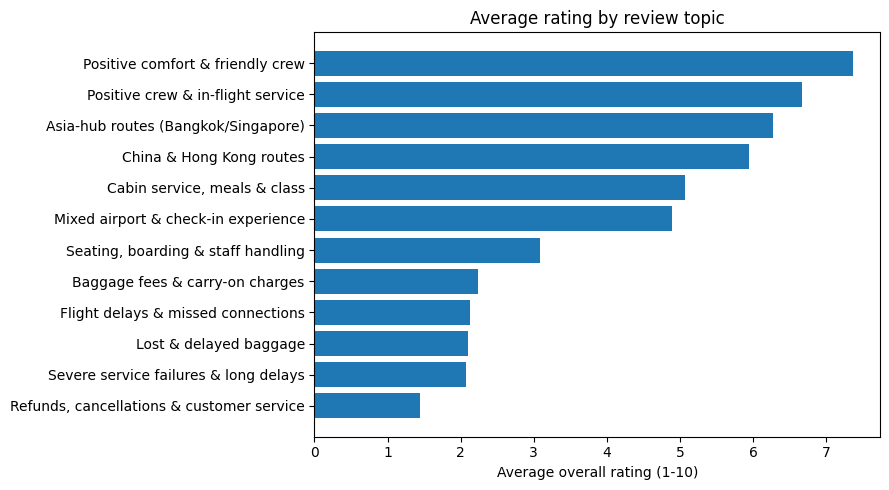

In [18]:
topic_names = {
    11: 'Refunds, cancellations & customer service',
    1:  'Severe service failures & long delays',
    3:  'Lost & delayed baggage',
    2:  'Flight delays & missed connections',
    9:  'Baggage fees & carry-on charges',
    7:  'Seating, boarding & staff handling',
    8:  'Mixed airport & check-in experience',
    0:  'Cabin service, meals & class',
    4:  'Positive crew & in-flight service',
    5:  'Asia-hub routes (Bangkok/Singapore)',
    6:  'China & Hong Kong routes',
    10: 'Positive comfort & friendly crew',
}
assert set(topic_names) == set(range(K))

sample['topic_name'] = sample['topic'].map(topic_names)
topic_summary['topic_name'] = topic_summary['topic'].map(topic_names)
print(topic_summary[['topic', 'topic_name', 'n_reviews', 'avg_rating', 'recommend_rate', 'top_terms']].to_string())

import matplotlib.pyplot as plt
ts = topic_summary.sort_values('avg_rating')
plt.figure(figsize=(9, 5))
plt.barh(ts['topic_name'], ts['avg_rating'])
plt.xlabel('Average overall rating (1-10)')
plt.title('Average rating by review topic')
plt.tight_layout()
plt.show()

In [19]:
sample.to_parquet(f'{DATA}/reviews_topics.parquet', index=False)
topic_summary.to_csv(f'{DATA}/topic_summary.csv', index=False)
with open(f'{DATA}/topic_names.json', 'w') as f:
    json.dump({int(k): v for k, v in topic_names.items()}, f, indent=2)

for f in ['embeddings.npy', 'faiss.index', 'reviews_topics.parquet', 'topic_summary.csv', 'topic_names.json']:
    print(f, round(os.path.getsize(f'{DATA}/{f}') / 1e6, 2), 'MB')

embeddings.npy 12.29 MB
faiss.index 12.29 MB
reviews_topics.parquet 3.74 MB
topic_summary.csv 0.0 MB
topic_names.json 0.0 MB
